# Train model

In [102]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'model'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [103]:
filename = os.path.join(context['portfolio_dir'], "features.parquet")
df = pd.read_parquet(filename)
# unisci le righe di tutti i dataframe in uno solo
df = df.dropna()
df.shape

(375553, 43)

## EDA

In [104]:
df.describe()

,AUDUSD,EURUSD,GBPUSD,GC,NZDUSD,USDCAD,USDCHF,USDJPY,^DJI,^GSPC,...,trend_50,vol_10,vol_20,vol_ratio,vol_regime,volume,volume_shock,volume_zscore,vwap,zscore_20
count,375553.000000,375553.000000,375553.000000,375553.000000,375553.000000,375553.000000,375553.000000,375553.000000,375553.000000,375553.000000,...,375553.000000,375553.000000,375553.000000,375553.000000,375553.000000,3.755530e+05,375553.000000,375553.000000,375553.000000,375553.000000
mean,0.655805,1.105528,1.291742,2814.076147,0.596731,1.374952,0.858643,149.313409,40912.413271,5557.430010,...,0.018148,0.043516,0.051048,0.872034,0.936115,2.851859e+06,1.026102,0.031759,102.128404,0.095797
std,0.018097,0.043248,0.041658,858.394529,0.018233,0.029133,0.043100,5.659850,4688.543464,845.719594,...,0.160310,0.043424,0.045873,0.277201,0.376363,7.202751e+06,0.637957,1.048047,149.111404,1.310761
min,0.595529,1.024443,1.207846,1816.599976,0.551849,1.311250,0.763200,133.464996,32417.589844,4055.989990,...,-0.922556,0.000682,0.001278,0.009301,0.006613,2.150000e+02,0.005890,-2.978068,0.045408,-4.248529
25%,0.644712,1.076299,1.261670,2030.500000,0.584030,1.356270,0.812580,145.473007,37710.101562,4783.450195,...,-0.047313,0.020879,0.026575,0.670394,0.669401,5.146410e+05,0.692261,-0.643451,23.464506,-0.961955
50%,0.655320,1.091822,1.279591,2616.800049,0.597190,1.370450,0.873910,149.167007,41113.968750,5611.850098,...,0.008138,0.032990,0.040179,0.890299,0.878413,1.153596e+06,0.891926,-0.240605,53.191686,0.144856
75%,0.666489,1.150933,1.332179,3332.500000,0.610620,1.389560,0.895460,154.145996,44461.281250,6118.709961,...,0.069264,0.053058,0.062237,1.090300,1.137053,2.636939e+06,1.172462,0.426169,116.447099,1.152917
max,0.712530,1.201764,1.382533,5318.399902,0.639190,1.471700,0.920970,161.606995,50188.140625,6978.600098,...,16.462674,1.942871,1.611193,1.448208,2.480680,3.902561e+08,20.000000,4.248529,2376.184086,4.248279


In [105]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 375553 entries, 482 to 619834
Data columns (total 41 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AUDUSD                 375553 non-null  float64
 1   EURUSD                 375553 non-null  float64
 2   GBPUSD                 375553 non-null  float64
 3   GC                     375553 non-null  float64
 4   NZDUSD                 375553 non-null  float64
 5   USDCAD                 375553 non-null  float64
 6   USDCHF                 375553 non-null  float64
 7   USDJPY                 375553 non-null  float64
 8   ^DJI                   375553 non-null  float64
 9   ^GSPC                  375553 non-null  float64
 10  ^IXIC                  375553 non-null  float64
 11  ^RUT                   375553 non-null  float64
 12  ^VIX1D                 375553 non-null  float64
 13  close_range            375553 non-null  float64
 14  country_Canada         375553 non-null  int64  
 1

In [106]:
# raise an error if there are any missing values
if df.isnull().values.any():
    raise ValueError("There are missing values in the dataframe")

## Target analysis

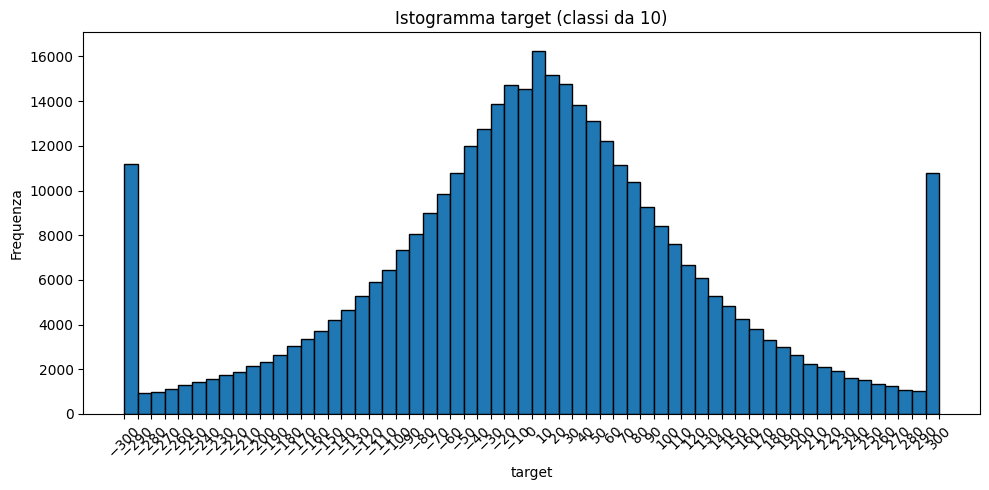

In [107]:
# Istogramma del target con classi (ampiezza) di 50
target_values = df['target']
target_values = target_values * 100
bin_start = math.floor(target_values.min() / 10) * 10
bin_end = math.ceil(target_values.max() / 10) * 10
bins = list(range(int(bin_start), int(bin_end) + 10, 10))

plt.figure(figsize=(10, 5))
plt.hist(target_values, bins=bins, edgecolor='black')
plt.title("Istogramma target (classi da 10)")
plt.xlabel("target")
plt.ylabel("Frequenza")
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

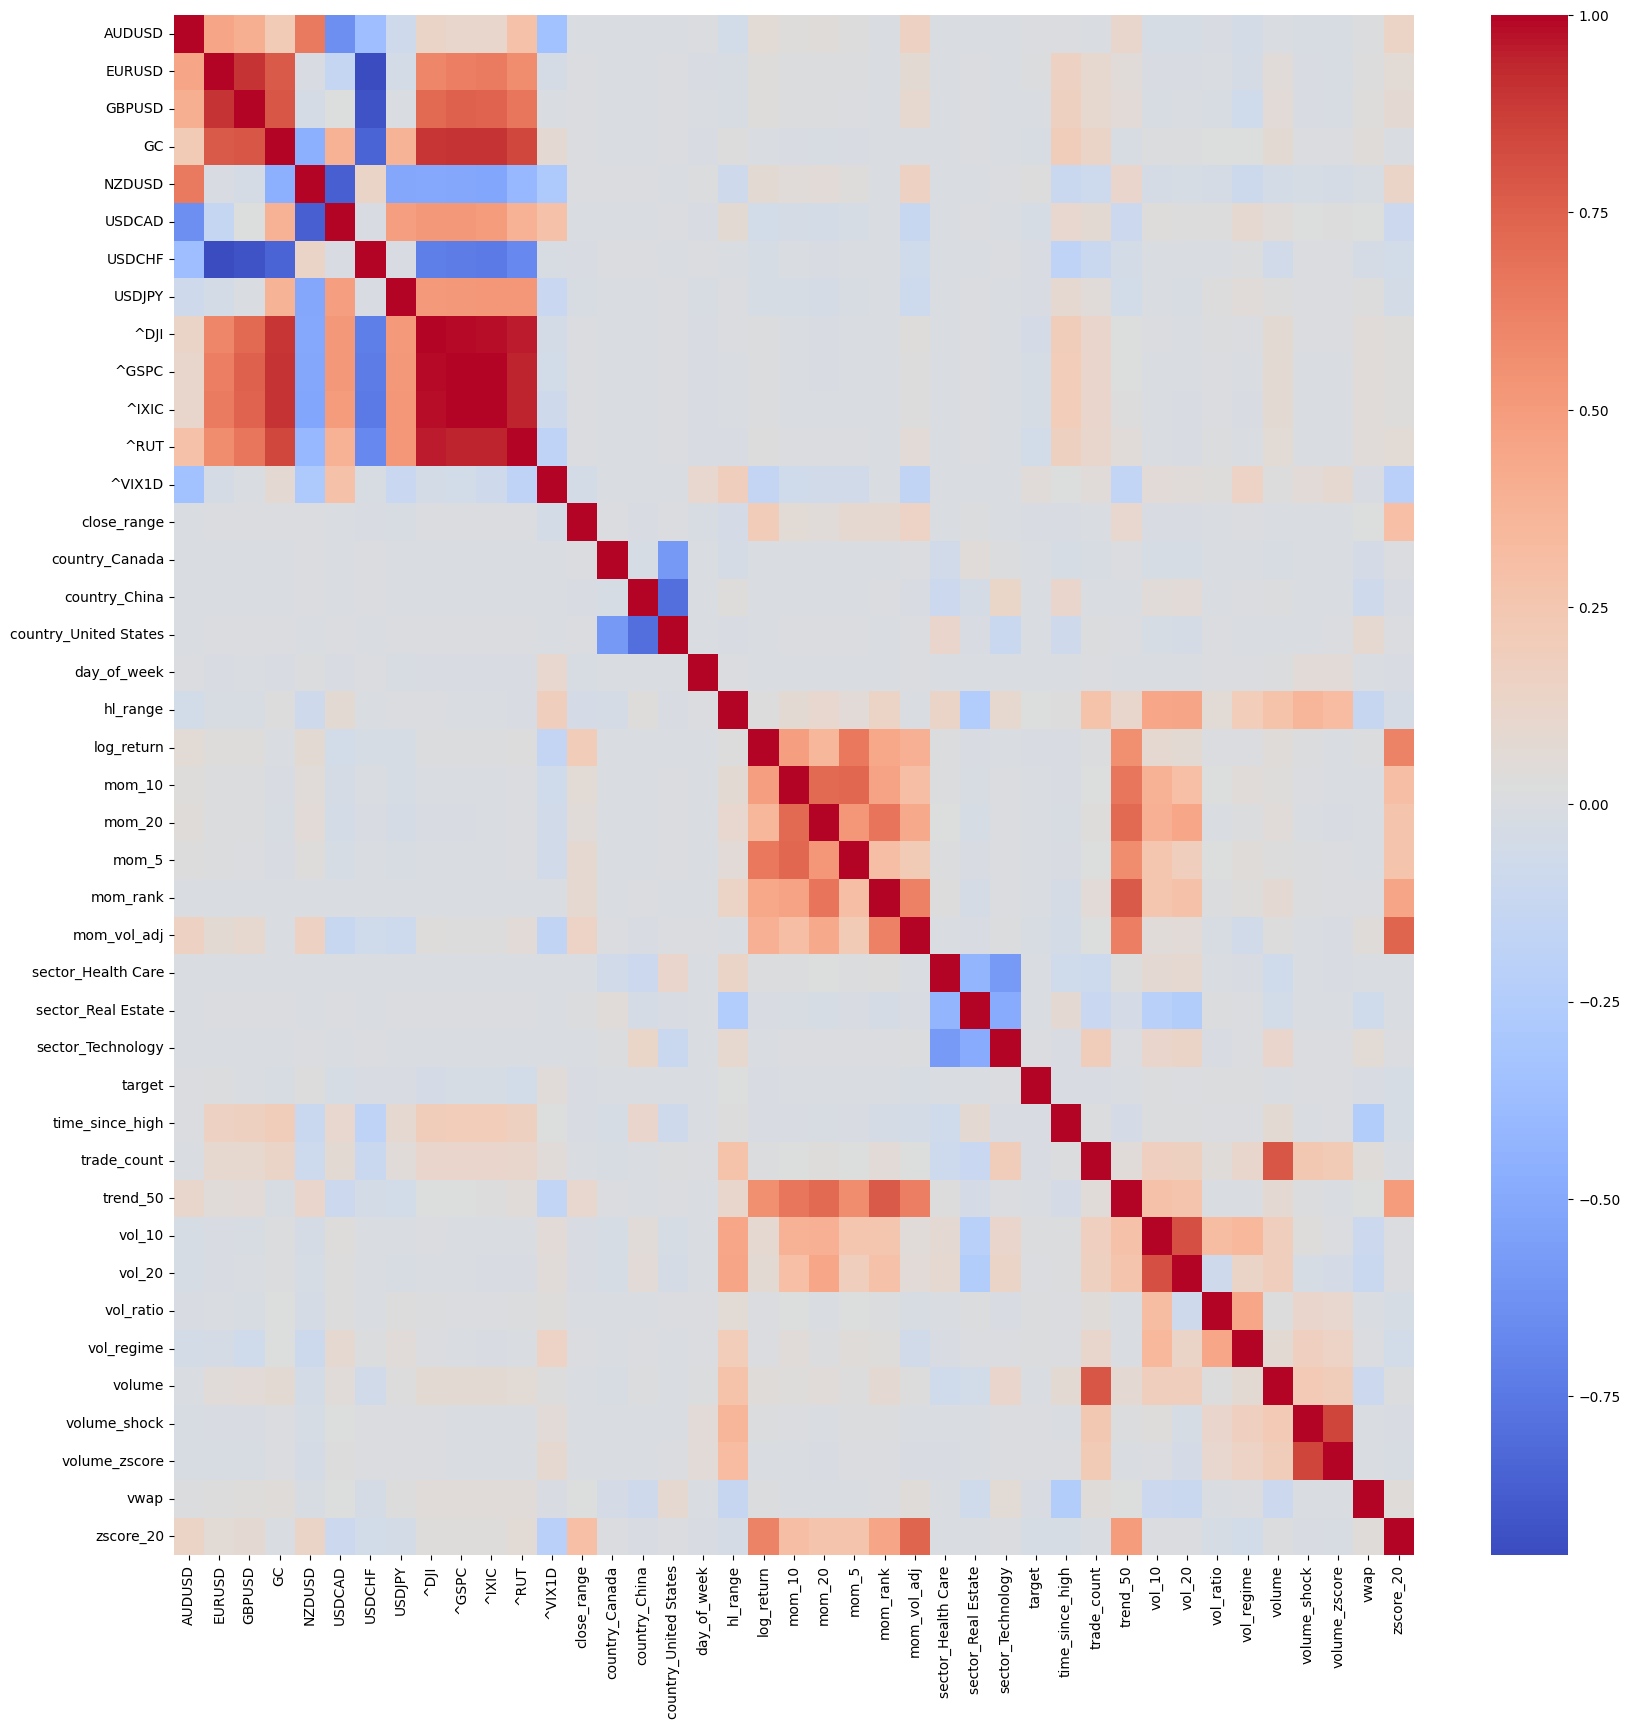

In [108]:
# display the correlation map using seaborn
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

## Normalize

In [109]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins['target']
label_max = maxs['target']
hayai_util.save_normalization_params(label_min, label_max)
maxs.index.name = "col"
maxs.name = "value"
maxs.to_csv(os.path.join(context['portfolio_dir'], "maxs.csv"), index=True)
mins.index.name = "col"
mins.name = "value"
mins.to_csv(os.path.join(context['portfolio_dir'], "mins.csv"), index=True)

## Model building

In [110]:
labels = df['target'].values
df = df.drop(columns=['target'])
data = df.values


In [111]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (375553,)
Data Shape: (375553, 40)
Train Data Shape: (300442, 40)
Train Labels Shape: (300442,)
Test Data Shape: (75111, 40)
Test Labels Shape: (75111,)


In [112]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(64, activation='relu',name='layerDense1'))
model.add(Dense(32, activation='relu',name='layerDense2'))
model.add(Dense(16, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/30
1878/1878 - 3s - 1ms/step - loss: 0.0432 - val_loss: 0.0419
Epoch 2/30
1878/1878 - 2s - 1ms/step - loss: 0.0414 - val_loss: 0.0409
Epoch 3/30
1878/1878 - 2s - 1ms/step - loss: 0.0404 - val_loss: 0.0402
Epoch 4/30
1878/1878 - 2s - 985us/step - loss: 0.0397 - val_loss: 0.0396
Epoch 5/30
1878/1878 - 2s - 1ms/step - loss: 0.0392 - val_loss: 0.0394
Epoch 6/30
1878/1878 - 2s - 1ms/step - loss: 0.0388 - val_loss: 0.0387
Epoch 7/30
1878/1878 - 2s - 1ms/step - loss: 0.0385 - val_loss: 0.0384
Epoch 8/30
1878/1878 - 2s - 1ms/step - loss: 0.0382 - val_loss: 0.0385
Epoch 9/30
1878/1878 - 2s - 1ms/step - loss: 0.0379 - val_loss: 0.0385
Epoch 10/30
1878/1878 - 3s - 1ms/step - loss: 0.0377 - val_loss: 0.0381
Epoch 11/30
1878/1878 - 2s - 1ms/step - loss: 0.0376 - val_loss: 0.0379
Epoch 12/30
1878/1878 - 2s - 1ms/step - loss: 0.0374 - val_loss: 0.0377
Epoch 13/30
1878/1878 - 2s - 1ms/step - loss: 0.0373 - val_loss: 0.0387
Epoch 14/30
1878/1878 - 2s - 1ms/step - loss: 0.0371 - val_loss: 0.0379

Model saved to: data\model\model.keras


In [114]:
tp = 0
tn = 0
fp = 0
fn = 0
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
print("min and max of predictions ", predictions.min(), predictions.max())
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

pred_denorm = predictions.flatten() * (label_max - label_min) + label_min
corr = pd.Series(labels).corr(pd.Series(pred_denorm))
print(f"Correlation (labels vs predictions): {corr:.4f}")

min and max of predictions  0.09802256 0.9165469
Label: 0.9902, Prediction: 0.2187
Label: -1.7058, Prediction: -0.6743
Label: -0.3784, Prediction: 0.0223
Label: -0.0312, Prediction: 0.0897
Label: -0.8171, Prediction: 0.3011
Label: -0.1517, Prediction: 0.2218
Label: 1.8219, Prediction: 0.2748
Label: -0.3348, Prediction: 0.1358
Label: 1.4646, Prediction: 0.0024
Label: 0.8937, Prediction: 0.5721
Label: -1.0748, Prediction: -1.1055
Label: 0.5278, Prediction: 0.3125
Label: -0.0165, Prediction: 0.1382
Label: -0.5513, Prediction: -0.4053
Label: -0.1447, Prediction: 0.6618
Label: -0.0326, Prediction: -0.0815
Label: 2.3140, Prediction: -0.1256
Label: 0.2667, Prediction: 0.0373
Label: 1.9899, Prediction: 0.2325
Label: 0.3039, Prediction: 0.0863
Label: 0.4327, Prediction: 0.5002
Label: 2.7741, Prediction: 1.3162
Label: 1.8422, Prediction: 0.0693
Label: -0.5174, Prediction: 0.1042
Label: -1.6129, Prediction: -0.8450
Label: -0.2842, Prediction: -0.0677
Label: 1.0240, Prediction: 0.4531
Label: 1.066